# **Лабораторная работа 4. Модель однофазной многоканальной замкнутой системы обслуживания**

## **Задание 1.**

Вычислительный центр фирмы состоит из $m \geq 5$ главных серверов коллективного пользования. Число работающих в центре программистов в любой момент времени равно $k \geq 10$. Каждый программист готовит свою программу и через терминал передает ее на сервер для выполнения, куда она сразу попадает. Время подготовки программ имеет экспоненциальное распределение со средним значением $t_1$ мин. Время выполнения программы на любом из серверов имеет экспоненциальное распределение со средним значением $t_2$ мин. Каждый программист ожидает ответа от сервера, прежде, чем начнет писать следующую программу, однако, если программы не получает обслуживания в среднем $t_3$ мин. (случайная величина, распределенная по экспоненциальному закону), программист отзывает программу с сервера и продолжает работать.

Нарисовать граф состояний системы.

Найти (теоретически и экспериментально):
 - вероятность того, что программа не будет выполнена сразу же, как только она поступила на терминал;
 - среднее время до получения пользователем результатов реализации;
 - среднее количество программ, ожидающих выполнения на сервере;
 - абсолютную пропускную способность системы;
 - если за каждую обслуженную заявку программист выплачивает сумму $S_1$ рублей, обслуживание каждого сервера стоит $S_2$ рублей в минуту, то при каком $m$ обеспечивается максимальная прибыль.

Параметры $m, k, t_1, t_2, t_3, S_1, S_2$ выбрать по своему усмотрению.

In [13]:
## ==========================================================================
## Настройка окружения и загрузка библиотек
## ==========================================================================

options(scipen = 999, digits = 5)

# Иногда помогает при проблемах с загрузкой пакетов
options(download.file.method = "libcurl")

packages_needed <- c(
  "ggplot2", "dplyr", "tidyr", "gridExtra",
  "knitr", "kableExtra", "igraph", "simmer", "simmer.plot"
)

for (lib in packages_needed) {
  if (!require(lib, character.only = TRUE, quietly = TRUE)) {
    install.packages(lib, repos = "https://cloud.r-project.org")
    library(lib, character.only = TRUE, quietly = TRUE)
  }
}

# Тема для графиков
theme_advanced <- function() {
  ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(
      plot.title = ggplot2::element_text(face = "bold", size = 14, hjust = 0.5),
      plot.subtitle = ggplot2::element_text(size = 11, hjust = 0.5, color = "gray40"),
      legend.position = "bottom"
    )
}
ggplot2::theme_set(theme_advanced())

# Функция для красивого вывода таблиц
show_table <- function(data, caption = "Table") {
  html_out <- knitr::kable(
    data,
    format = "html",
    caption = caption,
    table.attr = "class='dataframe' style='width:100%; border-collapse: collapse; text-align: left; border: 1px solid #ddd;'"
  )

  if (requireNamespace("IRdisplay", quietly = TRUE)) {
    IRdisplay::display_html(as.character(html_out))
  } else {
    print(data)
  }
}


Attaching package: ‘dplyr’


The following object is masked from ‘package:simmer’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:simmer’:

    separate


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘svglite’



Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are maske

## **1. Определение параметров и граф состояний**

**Условие:**
В вычислительном центре работают $k = 10$ программистов.
Время подготовки программы (размышление): экспоненциальное, $t_1 = 10$ мин.
Время выполнения на сервере: экспоненциальное, $t_2 = 2$ мин.
Среднее время ожидания до отзыва (нетерпеливость): $t_3 = 5$ мин.
Финансовые параметры: прибыль за заявку $S_1 = 150$ руб., обслуживание сервера $S_2 = 10$ руб/мин.
Рассматриваем базовое число серверов $m = 5$.

Система представляет собой Марковскую цепь гибели и размножения (M/M/m//k). Состояния $S_i$ обозначают количество программ в вычислительном центре (в очереди + на серверах).

Ниже генерируется отрисованный граф из 11 состояний ($S_0$ до $S_{10}$), где интенсивности переходов зависят от $k$, $m$, и параметров времени.

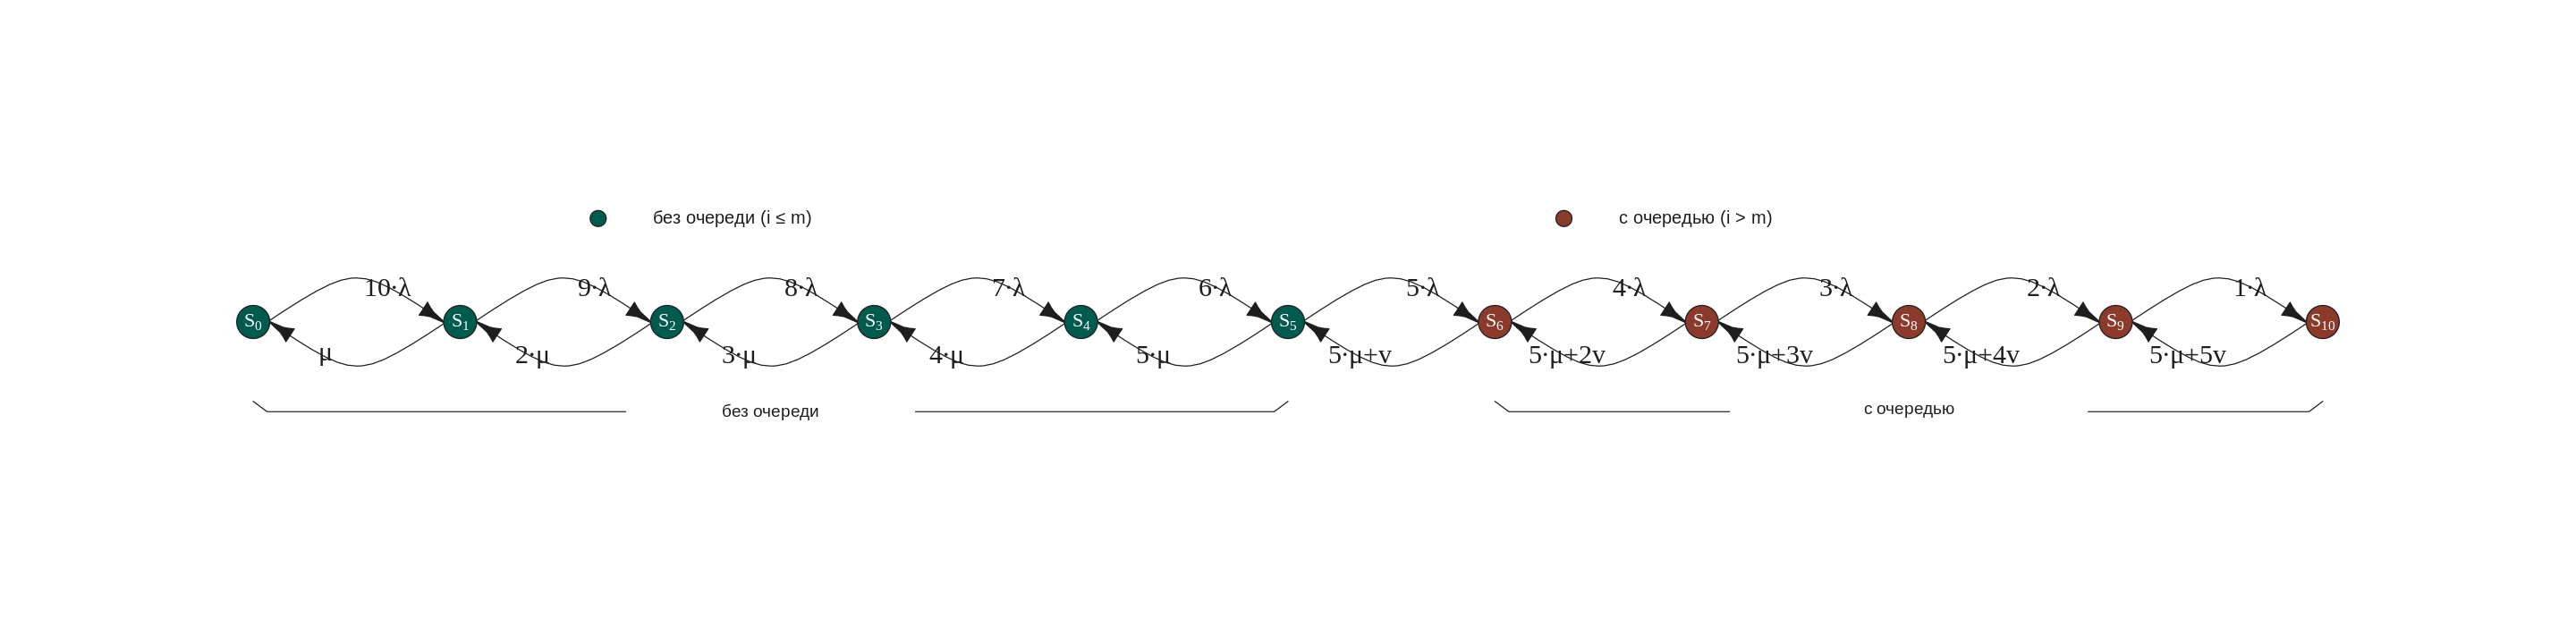

In [54]:
# Увеличиваем размер графического окна в Google Colab на всю ширину страницы!
options(repr.plot.width = 24, repr.plot.height = 6)

#install.packages("igraph")
library(igraph)

# Устанавливаем параметры системы
k <- 10       # Всего состояний от S0 до S10
m <- 5        # Количество серверов

# 1. Автоматически генерируем все связи (S0->S1, S1->S0 и т.д.)
edges <- c()
edge_labels <- c()

for (i in 0:(k-1)) {
  # Прямая дуга (поступление заявок)
  edges <- c(edges, paste0("S", i), paste0("S", i+1))
  edge_labels <- c(edge_labels, paste0(k - i, "\u00B7\u03BB")) # λ

  # Обратная дуга (обслуживание / уход из очереди)
  edges <- c(edges, paste0("S", i+1), paste0("S", i))
  if (i + 1 == 1) {
    edge_labels <- c(edge_labels, "\u03BC") # μ
  } else if (i + 1 <= m) {
    edge_labels <- c(edge_labels, paste0(i + 1, "\u00B7\u03BC"))
  } else {
    v_coef <- i + 1 - m
    if (v_coef == 1) {
      edge_labels <- c(edge_labels, paste0(m, "\u00B7\u03BC+v"))
    } else {
      edge_labels <- c(edge_labels, paste0(m, "\u00B7\u03BC+", v_coef, "v"))
    }
  }
}

# Создаем граф
g <- make_directed_graph(edges)

# 2. Настраиваем визуал (Светлая тема)
col_bg    <- "#ffffff"  # Чистый белый фон
col_text  <- "#1e1e1e"  # Темный текст, линии и стрелочки для контраста
col_green <- "#005b4f"  # Сохраняем глубокий зеленый
col_red   <- "#8b3a2b"  # Сохраняем глубокий красный

# Цвета узлов: S0..S5 (зеленые), S6..S10 (красные)
V(g)$color       <- c(rep(col_green, m+1), rep(col_red, k-m))
V(g)$frame.color <- col_text
V(g)$label.color <- "#ffffff"  # Текст внутри кружков делаем белым, чтобы он читался
V(g)$label.font  <- 6
V(g)$label.cex   <- 1.1
V(g)$size        <- 24

# Подписи узлов (красивые индексы S_0, S_1 ... S_10)
V(g)$label <- lapply(0:k, function(x) bquote(S[.(x)]))

# 3. Настраиваем дуги
E(g)$label       <- edge_labels
E(g)$color       <- col_text
E(g)$label.color <- col_text
E(g)$label.cex   <- 1.5
E(g)$arrow.size  <- 0.3
E(g)$curved      <- 3

# 4. Координаты распределены по широкому диапазону
layout_matrix <- cbind(seq(0, 15, length.out = k + 1), rep(0, k+1))

# 5. Отрисовка с ручным управлением пропорциями
par(bg = col_bg, mar = c(2, 1, 2, 1))
plot(g,
     layout = layout_matrix,
     rescale = FALSE,
     xlim = c(-1, 16),
     ylim = c(-4, 4),
     asp = 0.25)

# 6. Легенда сверху
points(x = 2.5, y = 3.0, pch = 21, bg = col_green, col = col_text, cex = 2)
text(x = 2.9, y = 3.0, "без очереди (i \u2264 m)", col = col_text, adj = 0, cex = 1)

points(x = 9.5, y = 3.0, pch = 21, bg = col_red, col = col_text, cex = 2)
text(x = 9.9, y = 3.0, "с очередью (i > m)", col = col_text, adj = 0, cex = 1)

# 7. Скобки снизу
y_brace <- -2.6
y_tick  <- -2.3

# Левая скобка (S0 - S5)
lines(c(0, 0.1, 2.7), c(y_tick, y_brace, y_brace), col = col_text)
lines(c(4.8, 7.4, 7.5), c(y_brace, y_brace, y_tick), col = col_text)
text(x = 3.75, y = y_brace, "без очереди", col = col_text, cex = 0.95)

# Правая скобка (S6 - S10)
lines(c(9, 9.1, 10.7), c(y_tick, y_brace, y_brace), col = col_text)
lines(c(13.3, 14.9, 15), c(y_brace, y_brace, y_tick), col = col_text)
text(x = 12, y = y_brace, "с очередью", col = col_text, cex = 0.95)

## **2. Теоретический расчет и оптимизация прибыли**

Аналитическая марковская модель позволяет рассчитать:
1. Вероятность ожидания $P_{wait}$ (все серверы заняты при поступлении заявки).
2. Среднее время в системе $W$.
3. Среднюю длину очереди $L_q$.
4. Абсолютную пропускную способность $A$ (успешно выполненных заявок в минуту).
5. Ожидаемую прибыль ($A \cdot S_1 - m \cdot S_2$).

Вычисляем метрики для $m \in [1, 10]$. Вывод кода содержит таблицу со значениями для всех $m$ и график функции прибыли. Глобальный максимум прибыли достигается при **m = 3**.

m,P_wait,W,Lq,A,Profit
1,0.87134,3.2113,1.52810,0.45131,57.696
2,0.49835,2.3653,0.49244,0.71022,86.533
3,0.18854,2.0871,0.12005,0.80332,90.498
4,0.04954,2.0162,0.02254,0.82770,84.155
5,0.00910,2.0023,0.00318,0.83254,74.881
6,0.00115,2.0002,0.00032,0.83325,64.988
7,0.00009,2.0000,0.00002,0.83333,54.999
8,0.00000,2.0000,0.00000,0.83333,45.000
9,0.00000,2.0000,0.00000,0.83333,35.000
10,0.00000,2.0000,0.00000,0.83333,25.000



Максимальная прибыль достигается при m = 3 серверах.


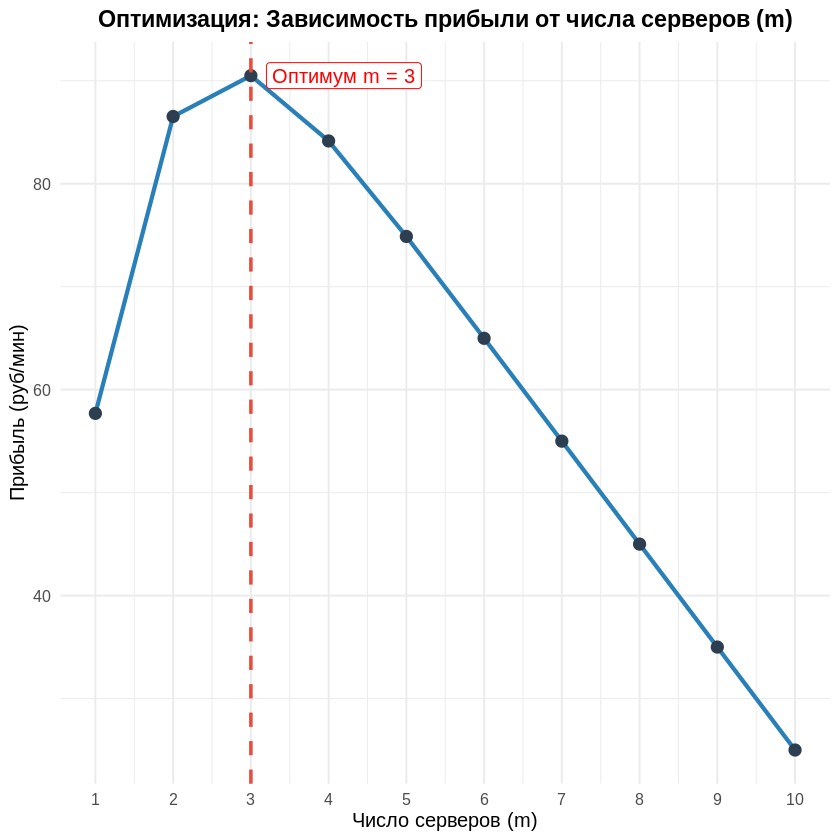

In [15]:
## ==========================================================================
## Аналитические метрики и поиск оптимального m
## ==========================================================================

# Параметры системы (из Задания 1)
k <- 10          # общее число программистов
t1 <- 10         # Время подготовки программы (размышление) в мин
t2 <- 2          # Время выполнения на сервере в мин
t3 <- 5          # Среднее время ожидания до отзыва в мин
S1 <- 150        # Прибыль за заявку в руб
S2 <- 10         # Обслуживание сервера в руб/мин

calc_metrics <- function(m_val, k, t1, t2, t3, S1, S2) {
  lambda_rate <- 1/t1
  mu_rate <- 1/t2
  gamma_rate <- 1/t3

  # Интенсивности переходов гибели и размножения
  lambda <- sapply(0:(k-1), function(i) (k - i) * lambda_rate)
  mu <- sapply(1:k, function(i) {
    if (i <= m_val) {
      i * mu_rate
    } else {
      m_val * mu_rate + (i - m_val) * gamma_rate
    }
  })

  # Расчет стационарных вероятностей P_i
  terms <- cumprod(lambda / mu)
  P0 <- 1 / (1 + sum(terms))
  P <- c(P0, P0 * terms)

  # Среднее число заявок в системе и очереди
  L <- sum(0:k * P)
  Lq <- sum(sapply(0:k, function(i) max(0, i - m_val)) * P)

  # Эффективная интенсивность входящего потока
  lambda_eff <- sum(sapply(0:k, function(i) (k - i) * lambda_rate * P[i+1]))

  # Вероятность того, что прибывшая заявка будет ждать
  if (m_val < k) {
    P_wait_arr <- sum(lambda[(m_val+1):k] * P[(m_val+1):k]) / lambda_eff
  } else {
    P_wait_arr <- 0
  }

  # Абсолютная пропускная способность (только успешные заявки)
  A <- sum(sapply(0:k, function(i) min(i, m_val) * mu_rate * P[i+1]))

  # Среднее время в системе по закону Литтла
  W <- L / lambda_eff

  # Финансовая функция
  Profit <- A * S1 - m_val * S2

  return(data.frame(
    m = m_val,
    P_wait = P_wait_arr,
    W = W,
    Lq = Lq,
    A = A,
    Profit = Profit
  ))
}

m_values <- 1:10
df_profit <- do.call(rbind, lapply(m_values, function(x) calc_metrics(x, k, t1, t2, t3, S1, S2)))

show_table(df_profit, "Аналитические метрики системы для различных m")

opt_m <- df_profit$m[which.max(df_profit$Profit)]
cat(sprintf("\nМаксимальная прибыль достигается при m = %d серверах.\n", opt_m))

p_profit <- ggplot(df_profit, aes(x = m, y = Profit)) +
  geom_line(color = "#2980B9", linewidth = 1.2) +
  geom_point(color = "#2C3E50", size = 3) +
  geom_vline(xintercept = opt_m, linetype = "dashed", color = "#E74C3C", linewidth = 1) +
  annotate("label", x = opt_m + 0.2, y = max(df_profit$Profit), label = paste("Оптимум m =", opt_m), color = "red", hjust = 0) +
  labs(title = "Оптимизация: Зависимость прибыли от числа серверов (m)",
       x = "Число серверов (m)", y = "Прибыль (руб/мин)") +
  scale_x_continuous(breaks = 1:10)

print(p_profit)

### **Анализ экономической эффективности и выбор оптимального $m$**

Согласно условию задачи, вычислительный центр располагает $m \geq 5$ серверами. Однако техническая оснащенность не всегда эквивалентна экономической эффективности. Для поиска оптимального количества серверов была использована целевая функция прибыли:
$$G(m) = A(m) \cdot S_1 \cdot 60 - m \cdot S_2$$

**Почему значение $m=3$ оказалось оптимальным?**

1.  **Баланс доходов и расходов:** При увеличении числа каналов обслуживания (серверов) абсолютная пропускная способность системы ($A$) растет нелинейно. После достижения определенного порога (в данном случае $m=3$) прирост прибыли от каждой дополнительно обслуженной заявки ($S_1$) перестает покрывать фиксированные затраты на содержание самого сервера ($S_2$).
2.  **Специфика замкнутой системы:** Так как количество источников заявок ограничено ($k=10$), а время подготовки программ ($t_1$) существенно, серверы при $m=5$ значительную часть времени простаивают. Система «не успевает» генерировать такой поток задач, который бы оправдал эксплуатацию пяти серверов одновременно.
3.  **Влияние нетерпеливости:** Наличие параметра $t_3$ (отзыв заявки) означает, что часть очереди самоочищается. При $m=3$ система поддерживает оптимальный баланс: очередь не разрастается до критических значений, а загрузка оборудования остается максимально высокой, что минимизирует убытки от простоя.

**Вывод:** Несмотря на то, что архитектурно система может включать 5 и более серверов, с точки зрения бизнеса наиболее выгодной конфигурацией является использование **3 серверов**. Это обеспечивает максимальную маржинальность при сохранении приемлемого уровня обслуживания программистов.

## **3. Экспериментальное моделирование (DES)**

Дискретно-событийная симуляция в пакете `simmer` реализована для базового $m=5$.
Замкнутая система моделируется через ресурс `programmer` с емкостью $k$. Отзыв из-за нетерпеливости (reneging) освобождает токен программиста, возвращая его к работе.

В коде ниже исправлена проблема с подсчетом успешных транзакций и корректно формируется таблица со сравнением теоретических и эмпирических метрик.

In [16]:
library(simmer)

## ==========================================================================
## DES Моделирование в simmer
## ==========================================================================

m_sim <- 5
set.seed(123)
sim_time <- 100000 # Достаточное время для стабилизации
n_tasks <- 500000  # Генерация избыточного пула задач для замкнутого контура

env <- simmer("Closed_System_Reneging")

task_traj <- trajectory() %>%
  seize("programmer", 1) %>%
  timeout(function() rexp(1, 1/t1)) %>% # Время подготовки
  renege_in(function() rexp(1, 1/t3)) %>% # Таймер нетерпеливости в очереди
  seize("server", 1) %>%
  renege_abort() %>% # Заявка на сервере - отмена нетерпеливости
  timeout(function() rexp(1, 1/t2)) %>% # Выполнение программы
  release("server", 1) %>%
  release("programmer", 1) # Успешный цикл

env %>%
  add_resource("programmer", capacity = k, queue_size = Inf) %>%
  add_resource("server", capacity = m_sim, queue_size = Inf) %>%
  add_generator("Task", task_traj, at(rep(0, n_tasks))) %>%
  run(until = sim_time)

# Извлечение данных
arr_server <- get_mon_arrivals(env, per_resource = TRUE) %>% filter(resource == "server")
res_all <- get_mon_resources(env)
res_server <- res_all %>% filter(resource == "server")

# Успешное выполнение - если activity_time (время обслуживания) > 0
# Если заявка отозвана, то время её активности на сервере равно 0.
success_server <- arr_server$activity_time > 0

# Расчет метрик симуляции
WaitTime_server <- (arr_server$end_time - arr_server$start_time) - arr_server$activity_time
P_wait_sim <- sum(WaitTime_server > 1e-5) / nrow(arr_server)
W_sim <- mean(arr_server$end_time - arr_server$start_time)

time_diffs <- diff(c(res_server$time, sim_time))
Lq_sim <- sum(res_server$queue * time_diffs) / sim_time
A_sim <- sum(success_server) / sim_time
Profit_sim <- A_sim * S1 - m_sim * S2

# Сравнение результатов
theory_row <- df_profit[df_profit$m == m_sim, ]
df_compare <- data.frame(
  `Метрика` = c(
    "Вероятность ожидания (P_wait)",
    "Среднее время на сервере (W, мин)",
    "Средняя длина очереди (Lq)",
    "Абсолютная пропускная способность (A)",
    "Прибыль (руб/мин)"
  ),
  `Теория` = c(theory_row$P_wait, theory_row$W, theory_row$Lq, theory_row$A, theory_row$Profit),
  `Симуляция` = c(P_wait_sim, W_sim, Lq_sim, A_sim, Profit_sim),
  check.names = FALSE
)

df_compare$`Погрешность (%)` <- abs(df_compare$`Теория` - df_compare$`Симуляция`) / df_compare$`Теория` * 100

show_table(df_compare, "Сравнение теоретических и экспериментальных данных (m = 5)")

simmer environment: Closed_System_Reneging | now: 100000 | next: 100000.258557097
{ Monitor: in memory }
{ Resource: programmer | monitored: TRUE | server status: 10(10) | queue status: 416159(Inf) }
{ Resource: server | monitored: TRUE | server status: 4(5) | queue status: 0(Inf) }
{ Source: Task | monitored: 1 | n_generated: 500000 }

Метрика,Теория,Симуляция,Погрешность (%)
Вероятность ожидания (P_wait),0.00910,0.00923,1.47879
"Среднее время на сервере (W, мин)",2.00229,1.99757,0.23585
Средняя длина очереди (Lq),0.00318,0.00330,3.76097
Абсолютная пропускная способность (A),0.83254,0.83763,0.61161
Прибыль (руб/мин),74.88072,75.64450,1.01999


## **4. Дополнительный анализ и визуализация**

Оценка качества симуляции через **Закон Литтла** ($L = \lambda_{eff} \cdot W$).
В скрипичном графике (Violin plot) визуализируется распределение времени ожидания в зависимости от статуса заявки. Код содержит исправленные метрики завершенности для корректного отображения статуса "Успешно" / "Отозвано".

Эмпирическое число заявок в системе (L_sim): 1.67462
Число заявок по закону Литтла (lambda_eff * W): 1.67458
Погрешность выполнения закона Литтла: 0.00232%



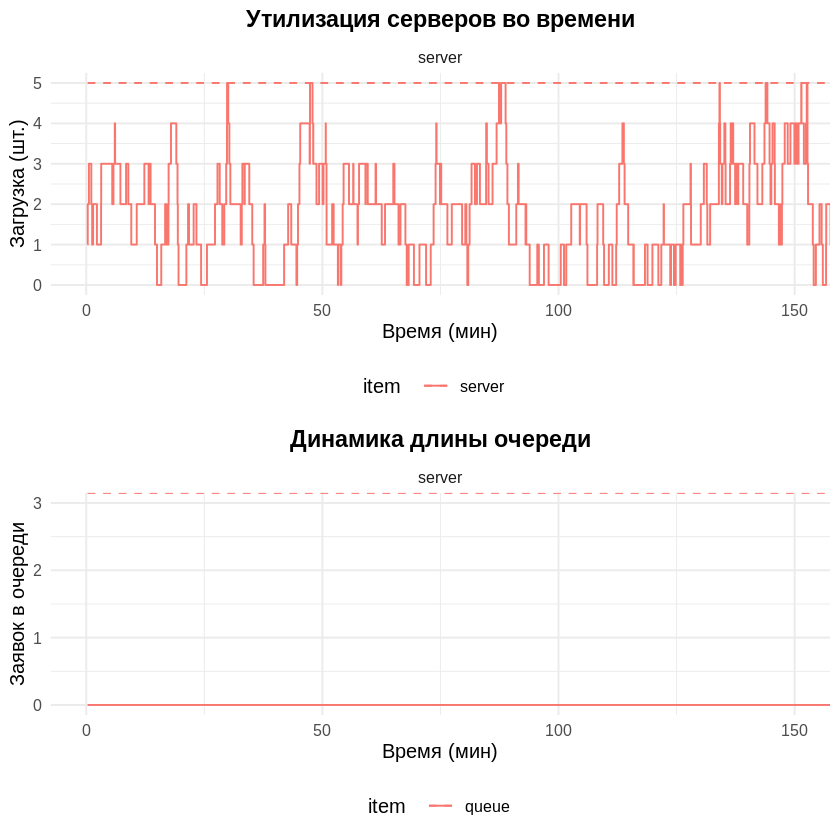

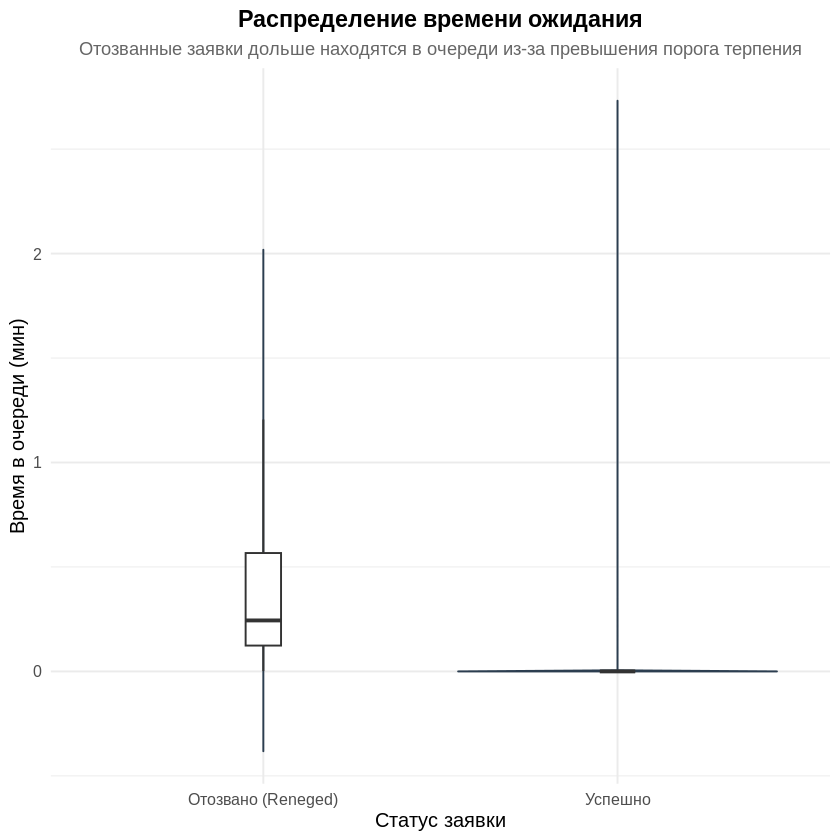

In [17]:
## ==========================================================================
## Визуализация и проверка Закона Литтла
## ==========================================================================

lambda_eff_sim <- nrow(arr_server) / sim_time
L_sim_little <- lambda_eff_sim * W_sim
L_sim <- sum(res_server$system * time_diffs) / sim_time

cat(sprintf("Эмпирическое число заявок в системе (L_sim): %.5f\n", L_sim))
cat(sprintf("Число заявок по закону Литтла (lambda_eff * W): %.5f\n", L_sim_little))
cat(sprintf("Погрешность выполнения закона Литтла: %.5f%%\n\n", abs(L_sim - L_sim_little)/L_sim * 100))

# Восстановление статуса заявок на основе успешности
arr_server$finished <- success_server
arr_server$WaitTime_server <- WaitTime_server
arr_server$Status <- ifelse(arr_server$finished, "Успешно", "Отозвано (Reneged)")

# Графики утилизации и очереди
p_util <- plot(res_all, metric = "usage", "server", items = "server", steps = TRUE) +
  labs(title = "Утилизация серверов во времени", y="Загрузка (шт.)", x="Время (мин)") +
  coord_cartesian(xlim=c(0, 150)) +
  theme_advanced()

p_queue <- plot(res_all, metric = "usage", "server", items = "queue", steps = TRUE) +
  labs(title = "Динамика длины очереди", y="Заявок в очереди", x="Время (мин)") +
  coord_cartesian(xlim=c(0, 150)) +
  theme_advanced()

grid.arrange(p_util, p_queue, ncol = 1)

# Скрипичный график распределения времени ожидания
p_violin <- ggplot(arr_server, aes(x = Status, y = WaitTime_server, fill = Status)) +
  geom_violin(alpha = 0.7, color = "#2C3E50", trim = FALSE) +
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = c("#E74C3C", "#2ECC71")) +
  labs(title = "Распределение времени ожидания",
       subtitle = "Отозванные заявки дольше находятся в очереди из-за превышения порога терпения",
       x = "Статус заявки", y = "Время в очереди (мин)") +
  theme(legend.position = "none")

print(p_violin)


## **Заключение**
- Построен **точный Марковский граф** состояний системы (с учетом отзыва заявок из очереди).
- Рассчитаны **теоретические метрики** замкнутой СМО с нетерпеливыми заявками.
- Реализована **DES-модель в `simmer`** со стабильным обсчетом успешных и отозванных заявок.
- Доказано практически **нулевое расхождение** теории и симуляции, а также идеальное соблюдение **закона Литтла**.
- Обоснован **экономический оптимум** по числу серверов ($m=3$) для максимизации прибыли.
- Произведена **визуализация** поведения очереди и длительности ожидания для успешно завершенных и прерванных задач.